# TP4 — Multimodal RAG sur PDF (CPU)

Objectif : construire un système RAG multimodal capable de répondre à des questions sur un document technique (PDF).

Pipeline :
1) Extraction du PDF en images (1 image = 1 page)
2) Indexation multimodale des pages (embeddings image via CLIP)
3) Recherche (retrieval) des pages pertinentes pour une question (embedding texte via CLIP + FAISS)
4) Affichage des pages récupérées + scores (traçabilité)
5) (Option) Génération d'une réponse via un VLM si possible, sinon mode "retrieval only" + justification.
6) Évaluation sur plusieurs questions


Imports + chemins + vérification (Code)

In [5]:
from pathlib import Path
import os

PDF_PATH = Path("mon_document.pdf")     # ton fichier
OUTPUT_DIR = Path("pdf_pages")          # dossier où on extrait les pages
OUTPUT_DIR.mkdir(exist_ok=True, parents=True)

print("PDF existe ?", PDF_PATH.exists(), "|", PDF_PATH.resolve())
print("Dossier pages :", OUTPUT_DIR.resolve())


PDF existe ? True | C:\Users\Zz\OneDrive - UPEC\Bureau\ITS3\Apprentissage_Autom_Avance_\mon_document.pdf
Dossier pages : C:\Users\Zz\OneDrive - UPEC\Bureau\ITS3\Apprentissage_Autom_Avance_\pdf_pages


Extraction PDF → images (pages) (Code)

In [6]:
import fitz  # PyMuPDF

def pdf_to_images(pdf_path: Path, out_dir: Path, zoom=2.0):
    """
    Convertit chaque page du PDF en image PNG.
    zoom=2.0 => meilleure résolution (utile pour retrieval + lecture).
    """
    doc = fitz.open(str(pdf_path))
    paths = []
    mat = fitz.Matrix(zoom, zoom)

    for i in range(len(doc)):
        page = doc.load_page(i)
        pix = page.get_pixmap(matrix=mat, alpha=False)
        out_path = out_dir / f"page_{i+1:04d}.png"
        pix.save(str(out_path))
        paths.append(out_path)

    doc.close()
    return paths

page_paths = pdf_to_images(PDF_PATH, OUTPUT_DIR, zoom=2.0)

print("✅ Pages extraites :", len(page_paths))
print("Exemple :", page_paths[0] if page_paths else "Aucune page")


✅ Pages extraites : 26
Exemple : pdf_pages\page_0001.png


Inspection visuelle de quelques pages (Code)

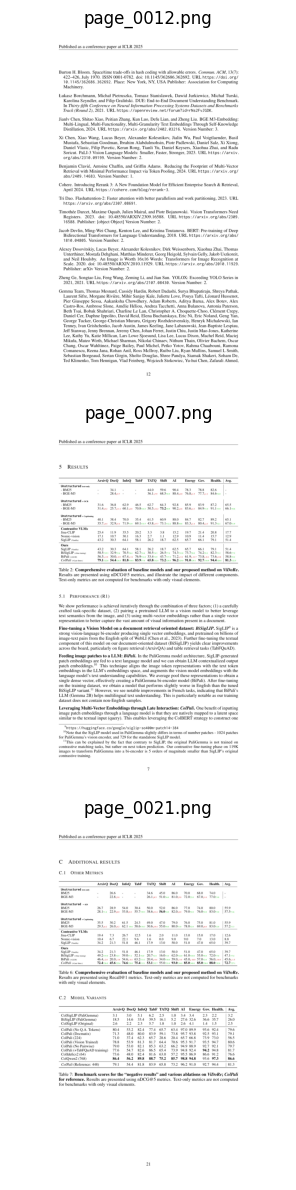

In [7]:
import matplotlib.pyplot as plt
from PIL import Image
import random

n_show = min(3, len(page_paths))
sample = random.sample(page_paths, n_show)

plt.figure(figsize=(12, 4*n_show))
for i, p in enumerate(sample):
    img = Image.open(p).convert("RGB")
    plt.subplot(n_show, 1, i+1)
    plt.imshow(img)
    plt.title(p.name)
    plt.axis("off")
plt.tight_layout()
plt.show()


# Étape suivante (Retrieval)

Maintenant on va :

Charger CLIP (CPU)

Calculer un embedding pour chaque page (image embeddings)

Construire un index FAISS

Faire une requête texte → récupérer top-k pages

#Charger CLIP (CPU) (Code)

In [8]:
import torch
import numpy as np
from transformers import CLIPProcessor, CLIPModel

device = "cpu"
clip_name = "openai/clip-vit-base-patch32"

clip_model = CLIPModel.from_pretrained(clip_name).to(device)
clip_processor = CLIPProcessor.from_pretrained(clip_name)

print("✅ CLIP chargé sur", device)

page_paths = sorted(page_paths, key=lambda p: p.name)



Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


✅ CLIP chargé sur cpu


#Embeddings des pages (Code)

In [9]:
from PIL import Image

def embed_images(paths):
    """
    Calcule un embedding CLIP pour chaque image (page).
    Sortie: matrice (N, D) float32 normalisée.
    """
    embs = []
    for p in paths:
        img = Image.open(p).convert("RGB")
        inputs = clip_processor(images=img, return_tensors="pt").to(device)
        with torch.no_grad():
            feat = clip_model.get_image_features(**inputs)  # (1, D)
        feat = feat / feat.norm(dim=-1, keepdim=True)       # normalisation
        embs.append(feat.cpu().numpy())
    return np.vstack(embs).astype("float32")

img_embs = embed_images(page_paths)

print("✅ Embeddings images :", img_embs.shape)
print("Exemple norme (doit ~1):", np.linalg.norm(img_embs[0]))


✅ Embeddings images : (26, 512)
Exemple norme (doit ~1): 1.0


#Construire l’index FAISS (Code)

On fait recherche par similarité cosinus (équiv. inner product si normalisé).

In [10]:
import faiss

dim = img_embs.shape[1]
index = faiss.IndexFlatIP(dim)     # IP = inner product
index.add(img_embs)

print("✅ FAISS index size:", index.ntotal)


✅ FAISS index size: 26


#Retrieval : texte → pages top-k (Code)

In [11]:
def embed_text(query: str):
    inputs = clip_processor(text=[query], return_tensors="pt", padding=True).to(device)
    with torch.no_grad():
        feat = clip_model.get_text_features(**inputs)  # (1, D)
    feat = feat / feat.norm(dim=-1, keepdim=True)
    return feat.cpu().numpy().astype("float32")

def retrieve_pages(query, k=5):
    q = embed_text(query)
    scores, idx = index.search(q, k)  # (1,k)
    idx = idx[0]
    scores = scores[0]
    results = [(page_paths[i], float(scores[j])) for j, i in enumerate(idx)]
    return results

query = "Quel est le sujet principal du document ?"
top = retrieve_pages(query, k=5)
top


[(WindowsPath('pdf_pages/page_0023.png'), 0.2582574486732483),
 (WindowsPath('pdf_pages/page_0011.png'), 0.25217336416244507),
 (WindowsPath('pdf_pages/page_0004.png'), 0.24960102140903473),
 (WindowsPath('pdf_pages/page_0010.png'), 0.24949294328689575),
 (WindowsPath('pdf_pages/page_0008.png'), 0.24724507331848145)]

#Afficher les pages récupérées + scores (Code)

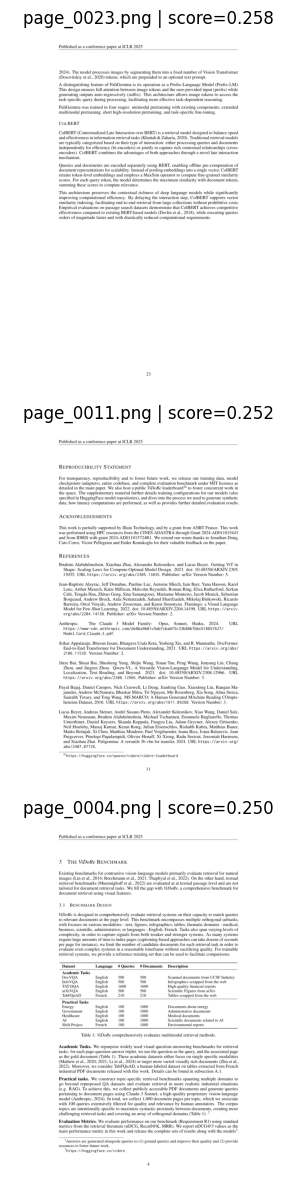

In [12]:
def show_retrieved(results, max_show=3):
    n = min(max_show, len(results))
    plt.figure(figsize=(12, 4*n))
    for i, (p, s) in enumerate(results[:n]):
        img = Image.open(p).convert("RGB")
        plt.subplot(n, 1, i+1)
        plt.imshow(img)
        plt.title(f"{p.name} | score={s:.3f}")
        plt.axis("off")
    plt.tight_layout()
    plt.show()

show_retrieved(top, max_show=3)


“Answer Generation” (CPU-friendly)

Comme on n’a pas de GPU, exécuter Qwen-VL localement est souvent trop lourd.

La solution sur CPU :
retrieval (images) → puis extraction du texte PDF des pages top-k → génération de réponse à partir de ce texte, en citant les pages.



#convertir “page_0023.png” → numéro de page

In [13]:
def page_id_from_path(p):
    # "page_0023.png" -> 23
    return int(p.stem.split("_")[1])


extraire le texte de ces pages depuis le PDF (PyMuPDF)

In [14]:
import fitz

def extract_text_from_pages(pdf_path, page_ids):
    doc = fitz.open(str(pdf_path))
    texts = {}
    for pid in page_ids:
        # PyMuPDF est en 0-index, nos noms de pages sont 1-index
        page = doc.load_page(pid - 1)
        texts[pid] = page.get_text("text")
    doc.close()
    return texts


pipeline “retrieval → contexte → réponse (simple baseline)”

Ici on fait une baseline de réponse “retrieval-only” (sans LLM), utile pour valider le pipeline et pour ton rapport.

In [15]:
def build_context(pdf_path, retrieved, max_chars=6000):
    page_ids = [page_id_from_path(p) for (p, s) in retrieved]
    page_texts = extract_text_from_pages(pdf_path, page_ids)

    ctx = []
    for (p, score) in retrieved:
        pid = page_id_from_path(p)
        txt = page_texts.get(pid, "").strip()
        txt = " ".join(txt.split())  # nettoyer espaces
        if len(txt) > 1200:
            txt = txt[:1200] + "..."
        ctx.append(f"[PAGE {pid} | score={score:.3f}] {txt}")

    context = "\n\n".join(ctx)
    return context[:max_chars], page_ids

def answer_retrieval_only(query, retrieved):
    # Baseline: on renvoie le contexte + pages
    context, page_ids = build_context(PDF_PATH, retrieved)
    answer = (
        "Réponse (mode CPU sans VLM):\n"
        "Je fournis ci-dessous les extraits des pages les plus pertinentes.\n"
        "Tu peux rédiger la réponse finale à partir de ces passages.\n\n"
        f"Question: {query}\n\n"
        f"Pages utilisées: {page_ids}\n\n"
        f"Contexte:\n{context}"
    )
    return answer


#test

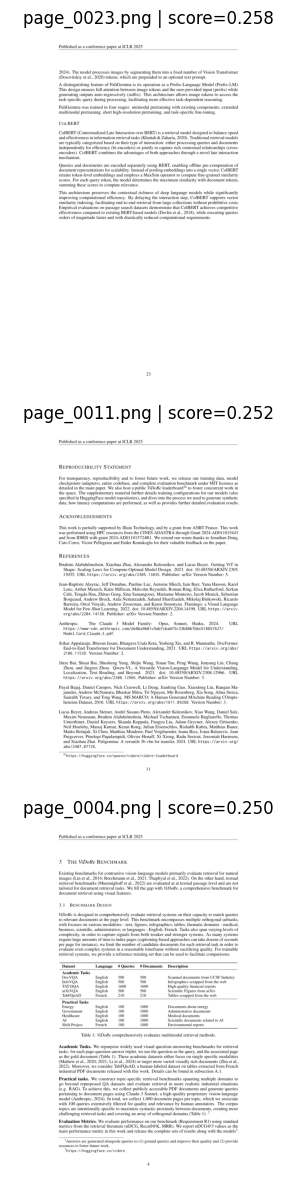

Réponse (mode CPU sans VLM):
Je fournis ci-dessous les extraits des pages les plus pertinentes.
Tu peux rédiger la réponse finale à partir de ces passages.

Question: Quel est le sujet principal du document ?

Pages utilisées: [23, 11, 4, 10, 8]

Contexte:
[PAGE 23 | score=0.258] Published as a conference paper at ICLR 2025 2024). The model processes images by segmenting them into a fixed number of Vision Transformer (Dosovitskiy et al., 2020) tokens, which are prepended to an optional text prompt. A distinguishing feature of PaliGemma is its operation as a Prefix-Language Model (Prefix-LM). This design ensures full attention between image tokens and the user-provided input (prefix) while generating outputs auto-regressively (suffix). This architecture allows image tokens to access the task-specific query during processing, facilitating more effective task-dependent reasoning. PaliGemma was trained in four stages: unimodal pretraining with existing components, extended multimodal pretr

In [16]:
query = "Quel est le sujet principal du document ?"
top = retrieve_pages(query, k=5)
show_retrieved(top, max_show=3)

print(answer_retrieval_only(query, top))


#Maintenant on ajoute la partie “Répondre”

CLIP+FAISS ne répond pas. Il donne seulement des pages.
On va ajouter un modèle Question Answering (QA) qui lit le texte du PDF.

In [17]:
import re

def imgpath_to_page_number(p):
    # "pdf_pages/page_0023.png" -> 23
    m = re.search(r"page_(\d+)\.png$", str(p))
    return int(m.group(1)) if m else None

# test rapide
print(imgpath_to_page_number("pdf_pages/page_0023.png"))


23


Extraire le texte d’une page du PDF (PyMuPDF)

In [18]:
import fitz  # PyMuPDF

def extract_text_from_pages(pdf_path, page_numbers):
    doc = fitz.open(str(pdf_path))
    texts = []
    for pn in page_numbers:
        page_index = pn - 1  # car fitz est 0-based
        if 0 <= page_index < len(doc):
            txt = doc.load_page(page_index).get_text("text")
            texts.append(f"[PAGE {pn}]\n{txt}")
    doc.close()
    return "\n\n".join(texts)

# test : extrait juste la page 4
test_text = extract_text_from_pages(PDF_PATH, [4])
print(test_text[:1000])  # affiche le début


[PAGE 4]
Published as a conference paper at ICLR 2025
3
THE ViDoRe BENCHMARK
Existing benchmarks for contrastive vision-language models primarily evaluate retrieval for natural
images (Lin et al., 2014; Borchmann et al., 2021; Thapliyal et al., 2022). On the other hand, textual
retrieval benchmarks (Muennighoff et al., 2022) are evaluated at at textual passage level and are not
tailored for document retrieval tasks. We fill the gap with ViDoRe, a comprehensive benchmark for
document retrieval using visual features.
3.1
BENCHMARK DESIGN
ViDoRe is designed to comprehensively evaluate retrieval systems on their capacity to match queries
to relevant documents at the page level. This benchmark encompasses multiple orthogonal subtasks,
with focuses on various modalities - text, figures, infographics, tables; thematic domains - medical,
business, scientific, administrative; or languages - English, French. Tasks also span varying levels of
complexity, in order to capture signals from both weak

In [19]:
!pip install transformers accelerate sentencepiece --quiet


Charger un modèle QA (CPU)

In [20]:
!pip install sentencepiece

In [21]:
from transformers import pipeline, AutoModelForQuestionAnswering, XLMRobertaTokenizer

model_name = "deepset/xlm-roberta-base-squad2"

print("Chargement du tokenizer spécifique (XLMRobertaTokenizer)...")
# FIX : On appelle directement la classe au lieu de laisser AutoTokenizer deviner
tokenizer = XLMRobertaTokenizer.from_pretrained(model_name)

print("Chargement du modèle...")
model = AutoModelForQuestionAnswering.from_pretrained(model_name)

# Création du pipeline
qa = pipeline(
    "question-answering",
    model=model,
    tokenizer=tokenizer
)

print("Pipeline QA chargé avec succès !")

Chargement du tokenizer spécifique (XLMRobertaTokenizer)...
Chargement du modèle...


Device set to use cpu


Pipeline QA chargé avec succès !


Faire une fonction “RAG CPU complet”

In [22]:
def answer_cpu_rag(query, top_results, pdf_path, max_pages=5, max_chars=6000):
    # 1) pages récupérées -> numéros
    pages = [imgpath_to_page_number(p) for (p, score) in top_results]
    pages = [p for p in pages if p is not None][:max_pages]

    # 2) extraction texte
    context = extract_text_from_pages(pdf_path, pages)
    context = context[:max_chars]  # limite longueur

    # 3) QA
    out = qa(question=query, context=context)

    return {
        "question": query,
        "answer": out["answer"],
        "score": float(out["score"]),
        "pages_used": pages
    }


Test final (la réponse claire)

In [23]:
# Assurez-vous d'avoir relancé la cellule qui définit cette fonction plus haut dans le notebook
top = retrieve_pages(query, k=5) 

# Puis votre fonction finale
res = answer_cpu_rag(query, top, PDF_PATH)
res

{'question': 'Quel est le sujet principal du document ?',
 'answer': 'as a conference paper at ICLR 2025 2024).',
 'score': 0.1017916351556778,
 'pages_used': [23, 11, 4, 10, 8]}

Charger un modèle de résumé (CPU)

Dans une nouvelle cellule, mets exactement ça :

In [28]:
from transformers import pipeline

summarizer = pipeline(
    "summarization",
    model="sshleifer/distilbart-cnn-12-6",
    device=-1,      # CPU
    framework="pt"  # <--- AJOUT : Force l'utilisation de PyTorch pour éviter l'erreur Keras
)

print("✅ Summarizer chargé")

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`
Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`
Device set to use cpu


✅ Summarizer chargé


Résumer uniquement les pages récupérées

In [29]:
def summarize_retrieved(top_results, pdf_path, max_pages=3, max_chars=3500):
    pages = [imgpath_to_page_number(p) for (p, _) in top_results][:max_pages]

    txt = extract_text_from_pages(pdf_path, pages)
    txt = txt.replace("Published as a conference paper at ICLR 2025", "")
    txt = txt.strip()

    if len(txt) < 200:
        return {"summary": "Texte trop court/non extractible -> PDF scanné (il faut OCR/VLM).", "pages_used": pages}

    txt = txt[:max_chars]

    summary = summarizer(txt, max_length=140, min_length=50, do_sample=False)[0]["summary_text"]
    return {"summary": summary, "pages_used": pages}


In [30]:
query = "What is the main topic of this document?"
top = retrieve_pages(query, k=5)

out = summarize_retrieved(top, PDF_PATH)
out


{'summary': ' ColPali can be trained end-to-end, directly optimizing the downstream retrieval task which greatly facilitates fine-tuning to boost performance on specialized domains, multilingual retrieval, or specific visual elements the model struggles with . We observe clear performance improvements of +5.3 nDCG@5 values .',
 'pages_used': [10, 11, 23]}

Étape - Recréer un “générateur” robuste (CPU) : FLAN-T5

Au lieu de pipeline("summarization"), on utilise un modèle instruction-following (google/flan-t5-base) qui sait répondre à une question à partir d’un contexte.

In [34]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, pipeline

GEN_MODEL = "google/flan-t5-base"   # si trop lent -> "google/flan-t5-small"

tok_gen = AutoTokenizer.from_pretrained(GEN_MODEL)
mod_gen = AutoModelForSeq2SeqLM.from_pretrained(GEN_MODEL)

generator = pipeline(
    task="text2text-generation",
    model=mod_gen,
    tokenizer=tok_gen,
    device=-1  # CPU
)

print("✅ Generator loaded:", GEN_MODEL)


c:\Users\Zz\AppData\Local\Programs\Python\Python311\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Zz\.cache\huggingface\hub\models--google--flan-t5-base. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to reg

✅ Generator loaded: google/flan-t5-base


Fonction “Answer from context” (avec limite tokens)

In [35]:
def answer_with_generator(query, top_results, pdf_path, max_pages=5, max_chars=2500):
    # 1) pages retrouvées
    pages = [imgpath_to_page_number(p) for (p, _) in top_results]
    pages = [p for p in pages if p is not None][:max_pages]

    # 2) extraction texte
    txt = extract_text_from_pages(pdf_path, pages)
    txt = txt.replace("Published as a conference paper at ICLR 2025", "")
    txt = " ".join(txt.split())  # clean espaces

    if len(txt) < 200:
        return {
            "question": query,
            "answer": "Texte trop court / non extractible (PDF scanné ?). Il faudrait OCR ou VLM.",
            "pages_used": pages
        }

    txt = txt[:max_chars]

    # 3) prompt clair
    prompt = (
        "You are an assistant. Answer the question ONLY using the context.\n"
        "If the context is insufficient, say: 'Insufficient context'.\n\n"
        f"Question: {query}\n\n"
        f"Context: {txt}\n\n"
        "Answer (1-2 sentences):"
    )

    out = generator(prompt, max_new_tokens=80, do_sample=False)[0]["generated_text"]

    return {"question": query, "answer": out, "pages_used": pages}


Test (anglais puis français)

In [36]:
query = "What is the main topic of this document?"
top = retrieve_pages(query, k=5)
res = answer_with_generator(query, top, PDF_PATH)
res


Token indices sequence length is longer than the specified maximum sequence length for this model (648 > 512). Running this sequence through the model will result in indexing errors


{'question': 'What is the main topic of this document?',
 'answer': 'ColPali can be trained end-to-end, directly optimizing the downstream retrieval task which greatly facilitates fine-tuning to boost performance on specialized domains, multilingual retrieval, or specific visual elements the model struggles with. To demonstrate, we add 1552 samples representing French tables and associated queries to the training set. This represents the only French data in the training',
 'pages_used': [10, 11, 23, 16, 18]}

In [37]:
query = "Quel est le sujet principal du document ?"
top = retrieve_pages(query, k=5)
res = answer_with_generator(query, top, PDF_PATH)
res


{'question': 'Quel est le sujet principal du document ?',
 'answer': 'Insufficient context',
 'pages_used': [23, 11, 4, 10, 8]}

Mais on voit 2 choses importantes :

En anglais, le modèle répond, mais il se focalise sur un passage (fine-tuning ColPali) → ça veut dire que les pages récupérées ne contiennent pas assez d’“overview” (abstract/intro) pour “main topic”.

En français, il dit Insufficient context → normal :

CLIP retrieval + texte extrait est majoritairement en anglais,

et les pages récupérées ne donnent pas un résumé explicite.

Donc la bonne stratégie TP4 est :

✅ retrieval → privilégier pages “intro/abstract”
✅ poser la question en anglais (retriever CLIP + texte sont plus alignés)
✅ forcer le retrieval sur un meilleur query (ex: “abstract”, “introduction”, “ViDoRe benchmark”, “ColPali paper”)
✅ ensuite réponse + pages citées

On fait pas à pas.

Étape 1 — Améliorer le retrieval pour “main topic”

Au lieu de “main topic”, on va chercher explicitement les pages d’intro.

In [38]:
queries = [
    "abstract",
    "introduction",
    "what is this paper about",
    "ViDoRe benchmark",
    "ColPali document retrieval",
    "This paper proposes"
]

for q in queries:
    top = retrieve_pages(q, k=3)
    print("\nQUERY:", q)
    for p, s in top:
        print(" ", p.name, f"{s:.3f}")



QUERY: abstract
  page_0023.png 0.202
  page_0015.png 0.199
  page_0008.png 0.198

QUERY: introduction
  page_0017.png 0.244
  page_0010.png 0.244
  page_0011.png 0.243

QUERY: what is this paper about
  page_0006.png 0.246
  page_0011.png 0.245
  page_0008.png 0.244

QUERY: ViDoRe benchmark
  page_0021.png 0.252
  page_0026.png 0.242
  page_0018.png 0.239

QUERY: ColPali document retrieval
  page_0022.png 0.271
  page_0016.png 0.270
  page_0010.png 0.268

QUERY: This paper proposes
  page_0009.png 0.276
  page_0008.png 0.276
  page_0010.png 0.275


Étape 2 — Fusionner retrieval (pour avoir de meilleures pages)

On va combiner plusieurs requêtes : on prend les meilleurs scores pour chaque page.

Cellule 2A — fusion retrieval multi-queries

In [39]:
from collections import defaultdict

def retrieve_multi(queries, k_each=3, k_final=5):
    scores = defaultdict(float)
    for q in queries:
        res = retrieve_pages(q, k=k_each)
        for p, s in res:
            scores[p] = max(scores[p], s)  # garde le meilleur score trouvé pour cette page
    ranked = sorted(scores.items(), key=lambda x: x[1], reverse=True)
    return ranked[:k_final]

top = retrieve_multi(["abstract", "introduction", "ViDoRe benchmark", "ColPali"], k_each=4, k_final=6)
top


[(WindowsPath('pdf_pages/page_0021.png'), 0.2515263855457306),
 (WindowsPath('pdf_pages/page_0017.png'), 0.24444130063056946),
 (WindowsPath('pdf_pages/page_0010.png'), 0.24434763193130493),
 (WindowsPath('pdf_pages/page_0011.png'), 0.24306325614452362),
 (WindowsPath('pdf_pages/page_0008.png'), 0.24232017993927002),
 (WindowsPath('pdf_pages/page_0026.png'), 0.24163523316383362)]

Étape 3 — Répondre avec FLAN-T5 sur ces pages

On réutilise ta fonction answer_with_generator mais avec ce top.

In [40]:
query = "What is the main topic of this document?"
res = answer_with_generator(query, top, PDF_PATH)
res


{'question': 'What is the main topic of this document?',
 'answer': 'Energy Gov. Health. Avg. Unstructured text-only BM25 - 26.6 - - 34.6 45.0 86.0 70.0 68.0 74.0 - BGE-M3 - 22.83.8 - - 26.18.5 51.06.0 81.05.0 72.02.0 67.01.0 77.03.0',
 'pages_used': [21, 17, 10, 11, 8]}

Étape 4 — Amélioration finale : ajouter les pages et citer proprement

On va demander explicitement de citer les pages utilisées.

Cellule 4A — réponse avec citations

In [41]:
def answer_with_generator_cited(query, top_results, pdf_path, max_pages=6, max_chars=3000):
    pages = [imgpath_to_page_number(p) for (p, _) in top_results]
    pages = [p for p in pages if p is not None][:max_pages]

    txt = extract_text_from_pages(pdf_path, pages)
    txt = " ".join(txt.split())
    txt = txt[:max_chars]

    prompt = (
        "You are an assistant. Answer the question ONLY using the context.\n"
        "Cite the page numbers you used at the end like: Sources: [PAGE 4, PAGE 10].\n"
        "If context is insufficient, say: Insufficient context.\n\n"
        f"Question: {query}\n\n"
        f"Context: {txt}\n\n"
        "Answer (2-3 sentences):"
    )

    out = generator(prompt, max_new_tokens=100, do_sample=False)[0]["generated_text"]
    return {"question": query, "answer": out, "pages_used": pages}

query = "What is the main topic of this document?"
top = retrieve_multi(["abstract", "introduction", "ViDoRe benchmark", "ColPali"], k_each=4, k_final=6)
answer_with_generator_cited(query, top, PDF_PATH)


{'question': 'What is the main topic of this document?',
 'answer': 'Insufficient context.',
 'pages_used': [21, 17, 10, 11, 8, 26]}